In [1]:
# Import libraries here

import numpy as np
import pandas as pd
import os
import sys
import matplotlib.pyplot as plt
import scipy.optimize as sco

In [2]:
current_dir = os.path.abspath('')
project_root = os.path.abspath(os.path.join(current_dir, '../../'))

if project_root not in sys.path:
    sys.path.append(project_root)

os.chdir(project_root)

print(f"Working directory set to: {os.getcwd()}")

Working directory set to: D:\users\kamen.dimitrov\desktop\softuni\math_concepts_for_developers\08_final_project


In [3]:
# Import modules here

import importlib
from src.portfolio_simulation_utils import portfolio_simulation as p_sim
from src.data_pipeline_utils import data_fetching_handling as data_pipe
importlib.reload(p_sim)
importlib.reload(data_pipe)

<module 'src.data_pipeline_utils.data_fetching_handling' from 'D:\\users\\kamen.dimitrov\\desktop\\softuni\\math_concepts_for_developers\\08_final_project\\src\\data_pipeline_utils\\data_fetching_handling.py'>

# Modern portfolio theory (MPT) is the hallmark of contemporary understanding of investment strategies. It first introduced the notion that: #

1. An investor can select an optimal portfolio, which maximizes return for a given level of risk
2. An investor can find a portfolio, which minimizes risk given a targeted return

This happens through diversification or owning many different risk-bearing assets instead of a few or a single one. For example owning shares only in Nvidia (NVDA) could make a great return as we see lately in the period between 2024 and 2025, but on the hand owning only Bitcoin (BTC) can brung great losses if we focus on the period between 2025 and March 2026. 

What is a risk asset exactly? The notion of risk is characterised by the variance of its daily price. 

[The founding study of MPT was published by scientist Harry Markowitz in 1952 and is simplistically described in my favorite online finance reference guide.](https://www.investopedia.com/terms/m/modernportfoliotheory.asp)

What did actually Markowitz solve? Mathematically and conceptually he introduced the following concepts:

#### 1. Portfolio variance: ####
$$ \sigma_p^2 = \sum_{i=1}^{n} w_i^2 \sigma_i^2 + \sum_{i \neq j} w_i w_j \operatorname{Cov}_{ij} $$

or in Matrix form if we take weights of assets in the portfolio and their individual expected returns as vectors:

$$ \sigma_p^2 = \mathbf{w}^\top \Sigma \mathbf{w} $$

In other words, portfolio risk includes:
- Variance of each asset
- Covariance between assets

Or this is the mathematics behind diversification. 

#### 2. The expected return of a portfolio ####
$$ \mu_p = \sum_{i=1}^{n} w_i \mu_i $$

#### 3. And the optimization solution is to minimize the portfolio variance: ####
$$ \min_{\mathbf{w}} \quad \mathbf{w}^\top \Sigma \mathbf{w} $$

if we assume that $ \mathbf{w}^\top \boldsymbol{\mu} = \mu_p $ is true and we are fully invested and without leverage $ \mathbf{1}^\top \mathbf{w} = 1 $

So Markowitz has applied a rule in Mathematics called the [generic Lagrange rule](https://alexkritchevsky.com/2024/06/10/lagrange-multipliers.html) in order to derive the below function seeking optimal solution for the portfolio variance given the two constraints:

$$ \mathcal{L}(\mathbf{w},\lambda,\gamma) = \mathbf{w}^\top \Sigma \mathbf{w} - \lambda (\mathbf{w}^\top \boldsymbol{\mu} - \mu_p) - \gamma (\mathbf{1}^\top \mathbf{w} - 1) $$

---

### Step 1: First we take the first derivative: ###

$$ \nabla_{\mathbf{w}} \mathcal{L} = 2\Sigma \mathbf{w} - \lambda \boldsymbol{\mu} - \gamma \mathbf{1} = 0 $$

---

### Step 2: Then we solve for weights in the portfolio as follows: ###

$$ 2\Sigma \mathbf{w} = \lambda \boldsymbol{\mu} + \gamma \mathbf{1} $$

---

### Step 3: Multiply both sides by the inverse covariance matrix ###

Multiply on the left by $\Sigma^{-1}$:

$$ \Sigma^{-1}(2\Sigma \mathbf{w}) = \Sigma^{-1}(\lambda \boldsymbol{\mu} + \gamma \mathbf{1}) $$

Since:

$$ \Sigma^{-1}\Sigma = I $$

(where $I$ is the identity matrix),

we obtain:

$$ 2\mathbf{w} = \lambda \Sigma^{-1}\boldsymbol{\mu} + \gamma \Sigma^{-1}\mathbf{1} $$

---

### Step 4: Divide both sides by 2

$$
\mathbf{w}
=
\frac{\lambda}{2}\Sigma^{-1}\boldsymbol{\mu}
+
\frac{\gamma}{2}\Sigma^{-1}\mathbf{1}
$$

This shows that the optimal weights are a linear combination of:

- $\Sigma^{-1}\boldsymbol{\mu}$ (risk-adjusted return direction)
- $\Sigma^{-1}\mathbf{1}$ (risk-adjusted budget direction)

---

## Step 5: Apply the Constraints

We now use the two constraints:

1. Target return:

$$
\mathbf{w}^\top \boldsymbol{\mu} = \mu_p
$$

2. Full investment:

$$
\mathbf{1}^\top \mathbf{w} = 1
$$

Substituting the expression for $\mathbf{w}$ into both constraints leads to repeated matrix expressions.

To simplify notation, we define:

$$
A = \mathbf{1}^\top \Sigma^{-1} \mathbf{1}
$$

$$
B = \mathbf{1}^\top \Sigma^{-1} \boldsymbol{\mu}
$$

$$
C = \boldsymbol{\mu}^\top \Sigma^{-1} \boldsymbol{\mu}
$$

We also define:

$$
D = AC - B^2
$$

---

## Step 6: Solving for the Multipliers

After substituting into the two constraints and solving the resulting 2×2 linear system, we obtain:

$$
\lambda = \frac{2(A\mu_p - B)}{D}
$$

$$
\gamma = \frac{2(C - B\mu_p)}{D}
$$

---

## Step 7: Efficient Frontier Equation

Substituting the optimal weights back into the portfolio variance:

$$
\sigma_p^2 = \mathbf{w}^\top \Sigma \mathbf{w}
$$

yields the closed-form equation of the efficient frontier:

$$
\sigma^2(\mu_p)
=
\frac{A\mu_p^2 - 2B\mu_p + C}{D}
$$

This is a quadratic function in $\mu_p$, which explains why the efficient frontier is a parabola in mean-variance space.

We again select the stock symbol tickers we like. Again let's keep them up to 10 for now. For the sake of experiments, let us keep them the same as in the notebook, where I practiced portfolio simulation.

In [4]:
tickers = ['AAPL', 'NVDA', 'MSFT', 'JNJ', 'BAC', 'VZ', 'WMT', 'UPS', 'PFE', 'JPM']

Let's build the now familiar Pandas dataframe returns_df

In [5]:
returns_df =  data_pipe.build_returns_df(tickers)

### Let's run calculations through theory as outlined ###

Some of the steps below look familiar to what we did with the monte carlo simulation. We would take the mean returns of the stocks, we will define the covariance matrix. Here I will show that we can construct a portfolio with equal weights of the stocks and through matrix multiplication we can define the expected portfolio return. While in the monte carlo we just randomly selected stock weights and calculated many different portfolios with their variance and return combinations, here we will apply the mathematical principles as outlined in the steps above.

In [6]:
trading_days = 252
mean_returns = returns_df.mean() * trading_days
cov_matrix = returns_df.cov() * trading_days

In [7]:
number_of_stocks = len(tickers)
weights = np.array([1 / number_of_stocks] * number_of_stocks)

In [8]:
# Calculate the expected portfolio return
expected_portfolio_return = mean_returns @ weights
print(expected_portfolio_return)

0.18224402903701814


In [9]:
# Calculate the inverse of the covariance matrix (Σ⁻¹)
inv_cov_matrix = np.linalg.inv(cov_matrix)
print(inv_cov_matrix)

[[ 24.52106745  -2.85229091 -10.79146481  -2.08740753  -1.82020101
   -0.30346205  -2.12812196  -2.95597147  -0.92328325  -0.28274576]
 [ -2.85229091   7.26799026  -6.03254463   2.15397344  -0.12699944
    1.41334316  -0.19976571  -0.8745795    0.34504678  -1.02299502]
 [-10.79146481  -6.03254463  31.63687735  -3.26401697  -0.08488909
   -0.47322573  -2.4534397   -1.23409886  -1.33523367  -2.49148485]
 [ -2.08740753   2.15397344  -3.26401697  46.94239391   1.27443259
   -7.25706895  -5.22721537  -1.63448542 -12.36210646  -4.0986047 ]
 [ -1.82020101  -0.12699944  -0.08488909   1.27443259  49.57011045
   -2.20198579  -0.36073273  -3.82065163  -0.39589068 -46.43639733]
 [ -0.30346205   1.41334316  -0.47322573  -7.25706895  -2.20198579
   31.56726738  -3.891144    -1.99024302  -3.37625837  -0.77011699]
 [ -2.12812196  -0.19976571  -2.4534397   -5.22721537  -0.36073273
   -3.891144    26.67113735  -1.9558322   -0.36553793   0.3021244 ]
 [ -2.95597147  -0.8745795   -1.23409886  -1.63448542  

In [10]:
# Define the vector of ones (1)
ones_vector = np.ones(number_of_stocks)
print(ones_vector)

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [11]:
# Compute A = 1^T Σ⁻¹ 1
A = ones_vector.T @ inv_cov_matrix @ ones_vector

# Compute B = 1^T Σ⁻¹ μ
B = ones_vector.T @ inv_cov_matrix @ mean_returns

# Compute C = μ^T Σ⁻¹ μ
C = mean_returns.T @ inv_cov_matrix @ mean_returns

# Compute D = AC - B^2
D = A * C - B**2

print(f"A = {A:.4f}")
print(f"B = {B:.4f}")
print(f"C = {C:.4f}")
print(f"D = {D:.4f}")

A = 49.4615
B = 5.8255
C = 2.2389
D = 76.8030


In [12]:
def calculate_optimal_weights(target_return, inv_cov, mu, ones, A, B, C, D):
    """
    Calculates the exact analytical weights for a given target return 
    allowing for short selling (unconstrained weights).
    """
    # Calculate Lagrange multipliers
    lambda_val = 2 * (A * target_return - B) / D
    gamma_val = 2 * (C - B * target_return) / D
    
    # Calculate optimal weights: w = (λ/2)Σ⁻¹μ + (γ/2)Σ⁻¹1
    w = (lambda_val / 2) * (inv_cov @ mu) + (gamma_val / 2) * (inv_cov @ ones)
    
    return w

def calculate_optimal_weights_for_range(target_returns, inv_cov, mu, ones, A, B, C, D):
    """
    Calculates the exact analytical weights for a given range of target returns 
    allowing for short selling (unconstrained weights).
    """

    frontier_weights = []
    
    for target_return in target_returns:
        lambda_val = 2 * (A * target_return - B) / D
        gamma_val = 2 * (C - B * target_return) / D
    
    
        w = (lambda_val / 2) * (inv_cov @ mu) + (gamma_val / 2) * (inv_cov @ ones)

        frontier_weights.append(w)
    
    return frontier_weights

In [13]:
# Solve the optimization for a target portfolio return
target_return_example = 0.20
optimal_weights = calculate_optimal_weights(
    target_return_example, inv_cov_matrix, mean_returns, ones_vector, A, B, C, D
)

print(f"Optimal weights for a {target_return_example*100}% return:")
print(pd.Series(optimal_weights, index=tickers))

Optimal weights for a 20.0% return:
AAPL    0.062926
NVDA    0.108083
MSFT    0.011613
JNJ     0.345671
BAC    -0.147602
VZ      0.171298
WMT     0.304445
UPS    -0.055370
PFE    -0.034862
JPM     0.233798
dtype: float64


In [14]:
def calculate_efficient_frontier_variance(target_returns, A, B, C, D):
    """
    Computes the closed-form variance for an array of target returns:
    σ²(μ_p) = (Aμ_p² - 2Bμ_p + C) / D
    """
    return (A * target_returns**2 - 2 * B * target_returns + C) / D

In [15]:
# Generate a range of target returns (e.g., from 0% to 40%)
target_returns_range = np.linspace(0.0, 0.40, 100)

# Calculate exact variances and volatilities (standard deviations)
analytical_variances = calculate_efficient_frontier_variance(target_returns_range, A, B, C, D)
analytical_volatilities = np.sqrt(analytical_variances)

At this point we have arrived at the solution of the original Harry Markowitz foundation of MPT! It gets very interesting to plot the results and observe:

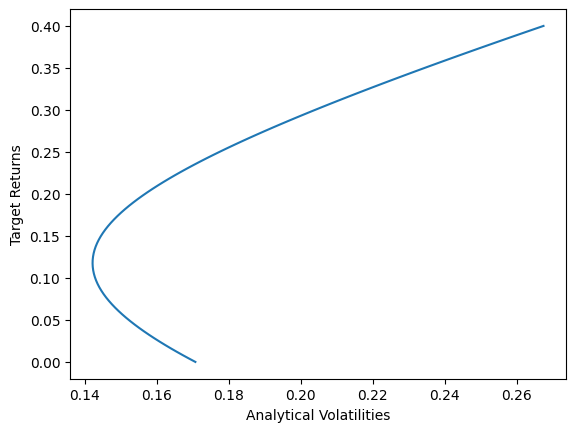

In [16]:
plt.plot(analytical_volatilities, target_returns_range)
plt.xlabel('Analytical Volatilities')
plt.ylabel('Target Returns')
plt.show()

### What can be observed? ###

The shape of the graph resembles strongly the output of the Monte Carlo simulation we have already performed!

Next I will calculate the weights of all portfolios lying on this curve.

In [17]:
frontier_weights = calculate_optimal_weights_for_range(target_returns_range, inv_cov_matrix, mean_returns, ones_vector, A, B, C, D)
print(frontier_weights)

[array([-0.07164163, -0.151325  ,  0.154335  ,  0.21497709, -0.00511051,
        0.38003579,  0.07493456,  0.22883379,  0.21557579, -0.04061487]), array([-0.0689231 , -0.14608443,  0.15145172,  0.21761738, -0.00798912,
        0.37581886,  0.07957114,  0.2230923 ,  0.21051643, -0.03507117]), array([-0.06620457, -0.14084387,  0.14856844,  0.22025767, -0.01086774,
        0.37160194,  0.08420772,  0.21735082,  0.20545707, -0.02952748]), array([-0.06348604, -0.1356033 ,  0.14568516,  0.22289795, -0.01374635,
        0.36738502,  0.0888443 ,  0.21160933,  0.20039771, -0.02398379]), array([-0.06076752, -0.13036273,  0.14280189,  0.22553824, -0.01662496,
        0.3631681 ,  0.09348088,  0.20586784,  0.19533835, -0.0184401 ]), array([-0.05804899, -0.12512216,  0.13991861,  0.22817853, -0.01950357,
        0.35895118,  0.09811746,  0.20012636,  0.19027899, -0.0128964 ]), array([-0.05533046, -0.1198816 ,  0.13703533,  0.23081882, -0.02238219,
        0.35473426,  0.10275404,  0.19438487,  0.18

### Conclusion ###

The theory is great, the mathematics behind is fascinating. It has become the norm in investment practice in the whole world. 

However, what do we observe - there is a negative weight in (almost) every portfolio weights combination forming the shape of the efficient frontier given the selected stock tickers for the example. What does a negative weight mean? This is short-selling, or selling something you do not own. But portfolios with short selling are rarely utilized by the mass investor. 

We need to tighten the constraint -> not only the weight sum up to one, but every weight is greater than or equal to zero, i.e. we do not allow to short sell stocks in order to construct our portfolio.

So this stops being a quadratic function of portfolio variance with two linear constraints. The math becomes extremely complex, and most of us struggle to understand even the seven steps above.

So we move to our next notebook 1_3 and put scientific and financial python libraries to work in order to order to define the function and seek its global minimum in order to identify the optimal portfolio and to plot the lowest-variance portfolios for each targeted return - the Markowitz efficient frontier. This time with long-only portfolios.